Ths notebook calculates the ternary disgram of the oil-water-surfactant system

In [37]:
import rdkit
from rdkit import Chem
from rdkit.Chem.Descriptors import MolWt
import numpy as np
from functions_for_surfactants import HLD_calculation
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ipywidgets as widgets 
from itertools import product
from functions_for_surfactants import draw_tubes_volumes, xi_calculation, len_calculation
from scipy.optimize import minimize_scalar
import ternary

**Enter parameters of the system**

Enter SMILES of your surfactant CCCCCCCCCCCCOCCOCCOCCOCCOCCO


Molecular weiight of the molecule is 406.60400000000027
Tail length is 38.129 Å
Vs_as 38.129 Å


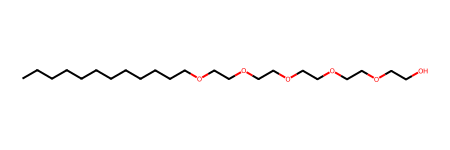

In [4]:
smi = input('Enter SMILES of your surfactant')
mol = Chem.MolFromSmiles(smi)

L = len_calculation(mol)
MWt = MolWt(mol)
print('Molecular weiight of the molecule is {}'.format(MWt))
print('Tail length is {} Å'.format(L))
Vs_as = MWt*10/(6.022*100)
print('Vs_as {} Å'.format(L))

mol

In [7]:
surfactant_selection = widgets.Dropdown(options = ['', 'Ionic', 'Nonionic'], value = '')
surfactant_selection

Dropdown(options=('', 'Ionic', 'Nonionic'), value='')

Calculate $\xi$

In [9]:
MWt_oil = float(input('Molecular weight of the oil'))
density = float(input('Density of the oil, g/cc'))
interfacial_area = float(input(r'Interfacial area Å2'))
xi = xi_calculation(L, interfacial_area, density, MWt_oil, surfactant_type=surfactant_selection.value)
print('Automatically calculated ξ is {}'.format(xi))

Molecular weight of the oil 198
Density of the oil, g/cc 0.76
Interfacial area Å2 67


Automatically calculated ξ is 836.163758230065


Type in ξ manually, if you don't want automatic calculations

In [11]:
xi = float(input('Your manual value of ξ'))
interfacial_area = float(input(r'Interfacial area Å2'))

Your manual value of ξ 125
Interfacial area Å2 68


Etner HLD parameters - nothing is varied here

In [13]:
EACN = float(input('Enter EACN value'))
Cc = float(input('Enter Cc value'))
Sal = float(input('Enter salinity value'))
Temp = float(input('Enter temperature value'))


Enter EACN value 14
Enter Cc value 0.88
Enter salinity value 0
Enter temperature value 47.8


Calculate HLD of the system and HLD of I->III and III->II transitions

In [15]:
HLD = HLD_calculation(EACN, Cc, Sal, Temp, Type = 'Nonionic')

In [23]:
HLDi_iii =  -2*L/xi
HLDiii_ii =  2*L/xi

Calculate Ro_d and Ro_w

In [27]:
# Ro_d and Rw_d calculation 

if HLD <  HLDi_iii:
    Ro_d = -L/HLD
    Rw_d = 1000
else:
    if HLD > HLDiii_ii:
        Ro_d = 1000
        Rw_d = L/HLD
    else:
        Ro_d = 2/(2/xi - HLD/L)
        Rw_d = 2/(2/xi + HLD/L)
print(Ro_d)
print(Rw_d)

102.76472110222291
159.5142073027881


Enter surfactant fraction in oil and water, respectively

In [29]:
fso = float(input('Enter fso value'))
fsw = float(input('Enter fsw value'))

Enter fso value 0.2
Enter fsw value 0.2


**ME + excess oil phase boundary line**

In [31]:
#objective funtion for minimization
#phi_s_fl - ratio pof surfactant to fluid
def R_calculation(phi_s_fl, fs, R_d):
    Rws = 3 * (1-phi_s_fl+fs*phi_s_fl)*Vs_as/phi_s_fl
    Rw = 3 * (1-phi_s_fl)*Vs_as/phi_s_fl
    Ros = 1/(1/Rws-1/Rw+1/R_d)
    return (Rws, Rw, Ros)


def obj_fn(phi_s_fl, fs, R_d):
    return 1000/np.abs(R_calculation(phi_s_fl, fs, R_d)[2])

res = minimize_scalar(obj_fn, args = (fsw, Ro_d), bounds  = (0,1), method='bounded')

phi_s_aq = np.linspace(0.01, res.x, 30)


In [43]:
Ros = R_calculation(phi_s_aq, fsw, Ro_d)[2]
phi_s_o = 1/(Ros/(3*Vs_as)+1-fso)
phi_o = (1/phi_s_o-1)/((1/phi_s_o-1)+(1/phi_s_aq-1)+1)
phi_s = 1/(1+(1/phi_s_o-1)+(1/phi_s_aq-1))
phi_w = 1 - phi_o - phi_s

In [47]:
ME_oil_exc_points = []

for w, o, s in zip(phi_w, phi_o, phi_s):
    ME_oil_exc_points.append((o, s, w))


**ME + excess water phase boundary line**

In [54]:
res = minimize_scalar(obj_fn, args = (fso, Rw_d), bounds  = (0,1), method='bounded')
phi_s_o = np.linspace(0.01, res.x, 30)


In [60]:
Rws = R_calculation(phi_s_o, fso, Rw_d)[2]
phi_s_aq = 1/(Rws/(3*Vs_as)+1-fsw)
phi_o = (1/phi_s_o-1)/((1/phi_s_o-1)+(1/phi_s_aq-1)+1)
phi_s = 1/(1+(1/phi_s_o-1)+(1/phi_s_aq-1))
phi_w = 1 - phi_o - phi_s

ME_water_exc_points = []

for w, o, s in zip(phi_w, phi_o, phi_s):
    ME_water_exc_points.append((o, s, w))

Plotting two tielines

(-0.05, 1.05, -0.1, 0.9)

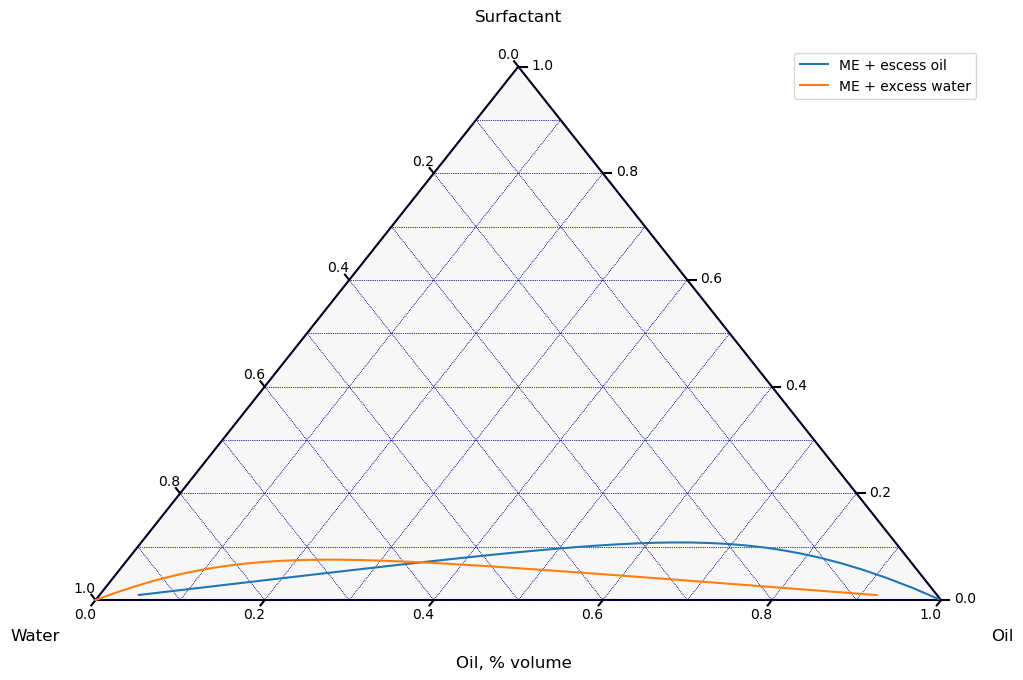

In [169]:
fig, ax = plt.subplots(1, 1, figsize = (12,8))
fig, tax = ternary.figure(scale = 1, ax = ax)
tax.boundary(linewidth=1.5)
tax.gridlines(color="black", multiple=0.1)
tax.gridlines(color="blue", multiple=0.1, linewidth=0.5)

#tax.left_axis_label("Left label $\\alpha^2$", fontsize=12)
#tax.right_axis_label("Right label $\\beta^2$", fontsize=12)
tax.top_corner_label('Surfactant', fontsize = 12)
tax.right_corner_label('Oil', fontsize = 12)
tax.left_corner_label('Water', fontsize = 12)

tax.bottom_axis_label("Oil, % volume", fontsize = 12)
tax.plot(ME_oil_exc_points, label = 'ME + escess oil')
tax.ticks(multiple = 0.2, tick_formats="%.1f", offset = 0.01)
tax.plot(ME_water_exc_points, label = 'ME + excess water')
tax.legend()
tax.clear_matplotlib_ticks()
tax.get_axes().axis('off')

